In [1]:
import matplotlib.pyplot as plt
import numpy as np
import random
import torch
import torch.nn.functional as F

from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Device is set to: {device}")

Device is set to: cuda


# Read Files

In [3]:
def read_vocabulary_from_file(filename):
    with open(filename, 'r', encoding="ISO−8859−1") as f:
        content = f.readlines()
        content = [x.strip() for x in content]
        content = [c for c in content if not c.startswith(';') and c and not c.endswith('+')]
        return content

In [4]:
negative_words = read_vocabulary_from_file('negative-words.txt')
positive_words = read_vocabulary_from_file('positive-words.txt')

In [5]:
print(f"Number of negative words: {len(negative_words)}")
print(f"Number of positive words: {len(positive_words)}")

Number of negative words: 4783
Number of positive words: 2005


# Embedding

In [6]:
def load_glove_embeddings(filename):
    embeddings = {}
    with open(filename, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.strip().split()
            w = values[0]
            vectors = np.array(values[1:], dtype='float32')
            embeddings[w] = vectors
    return embeddings

word_dict = load_glove_embeddings('glove.6B.50d.txt')

# Data Split

In [7]:
random.shuffle(positive_words)
random.shuffle(negative_words)

positive_vectors = [word_dict[word] for word in positive_words if word in word_dict]
negative_vectors = [word_dict[word] for word in negative_words if word in word_dict]

print(f"Number of positive words after Glove: {len(positive_vectors)}")
print(f"Number of negative words after Glove: {len(negative_vectors)}")

Number of positive words after Glove: 1893
Number of negative words after Glove: 4345


In [8]:
X_train = torch.cat((
    torch.tensor(negative_vectors)[:1500],
    torch.tensor(positive_vectors)[:1500]
))
y_train = torch.cat((
    torch.ones(1500, dtype=torch.long),
    torch.zeros(1500, dtype=torch.long)
))

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

assert X_train.shape[0] == y_train.shape[0]

C:\Users\micha\AppData\Local\Temp\ipykernel_53732\1343735617.py:2: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  torch.tensor(negative_vectors)[:1500],


In [9]:
X_test = torch.cat((
    torch.tensor(negative_vectors)[1500:],
    torch.tensor(positive_vectors)[1500:]
))
y_test = torch.cat((
    torch.ones(len(torch.tensor(negative_vectors)[1500:]), dtype=torch.long),
    torch.zeros(len(torch.tensor(positive_vectors)[1500:]), dtype=torch.long)
))

test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

assert X_test.shape[0] == y_test.shape[0]

# Defining the Model

In [10]:
class PolarityClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes = 2):
        super(PolarityClassifier, self).__init__()

        self.linear1 = nn.Linear(input_dim, hidden_dim)
        self.linear2 = nn.Linear(hidden_dim, hidden_dim)
        self.output = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = F.relu(self.linear1(x))
        x = F.relu(self.linear2(x))
        return self.output(x)

# Training Loop

In [11]:
def run_epoch(model, dataloader, optimizer, criterion, train=True):
    """
    Runs one epoch for training or validation.
    """
    epoch_loss = 0
    correct = 0
    total_samples = len(dataloader.dataset)
    total_preds = []
    total_targets = []

    if train:
        model.train()
    else:
        model.eval()

    for X, y in dataloader:
        X, y = X.to(device), y.to(device)

        if train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train):
            output = model(X)
            loss = criterion(output, y.long().squeeze())

        epoch_loss += loss.item()
        _, y_pred = torch.max(output, dim=1)
        correct += torch.sum(y_pred == y).item()

        if train:
            loss.backward()
            optimizer.step()
        else:
            total_preds.append(y_pred.detach().cpu())
            total_targets.append(y.detach().cpu())

    avg_loss = epoch_loss / len(dataloader)
    accuracy = correct / total_samples

    return avg_loss, accuracy, total_preds, total_targets

def trainer(model, train_loader, val_loader, optimizer, criterion, n_epochs):
    """
    Trains and evaluates the model for n_epochs.
    """
    epoch_train_losses = []
    epoch_val_losses = []
    epoch_train_accs = []
    epoch_val_accs = []
    total_preds, total_targets = None, None

    for _ in tqdm(range(n_epochs), desc=f"Epoch"):
        train_loss, train_acc, _, _ = run_epoch(model, train_loader, optimizer, criterion, train=True)
        val_loss, val_acc, total_preds, total_targets = run_epoch(model, val_loader, optimizer, criterion, train=False)

        epoch_train_losses.append(train_loss)
        epoch_val_losses.append(val_loss)
        epoch_train_accs.append(train_acc)
        epoch_val_accs.append(val_acc)

    return epoch_train_losses, epoch_val_losses, epoch_train_accs, epoch_val_accs, total_preds, total_targets

Run 1 with hidden_size 128.


Epoch: 100%|██████████| 20/20 [00:02<00:00,  6.85it/s]


Run 2 with hidden_size 256.


Epoch: 100%|██████████| 20/20 [00:02<00:00,  6.80it/s]


Run 3 with hidden_size 512.


Epoch: 100%|██████████| 20/20 [00:02<00:00,  7.36it/s]


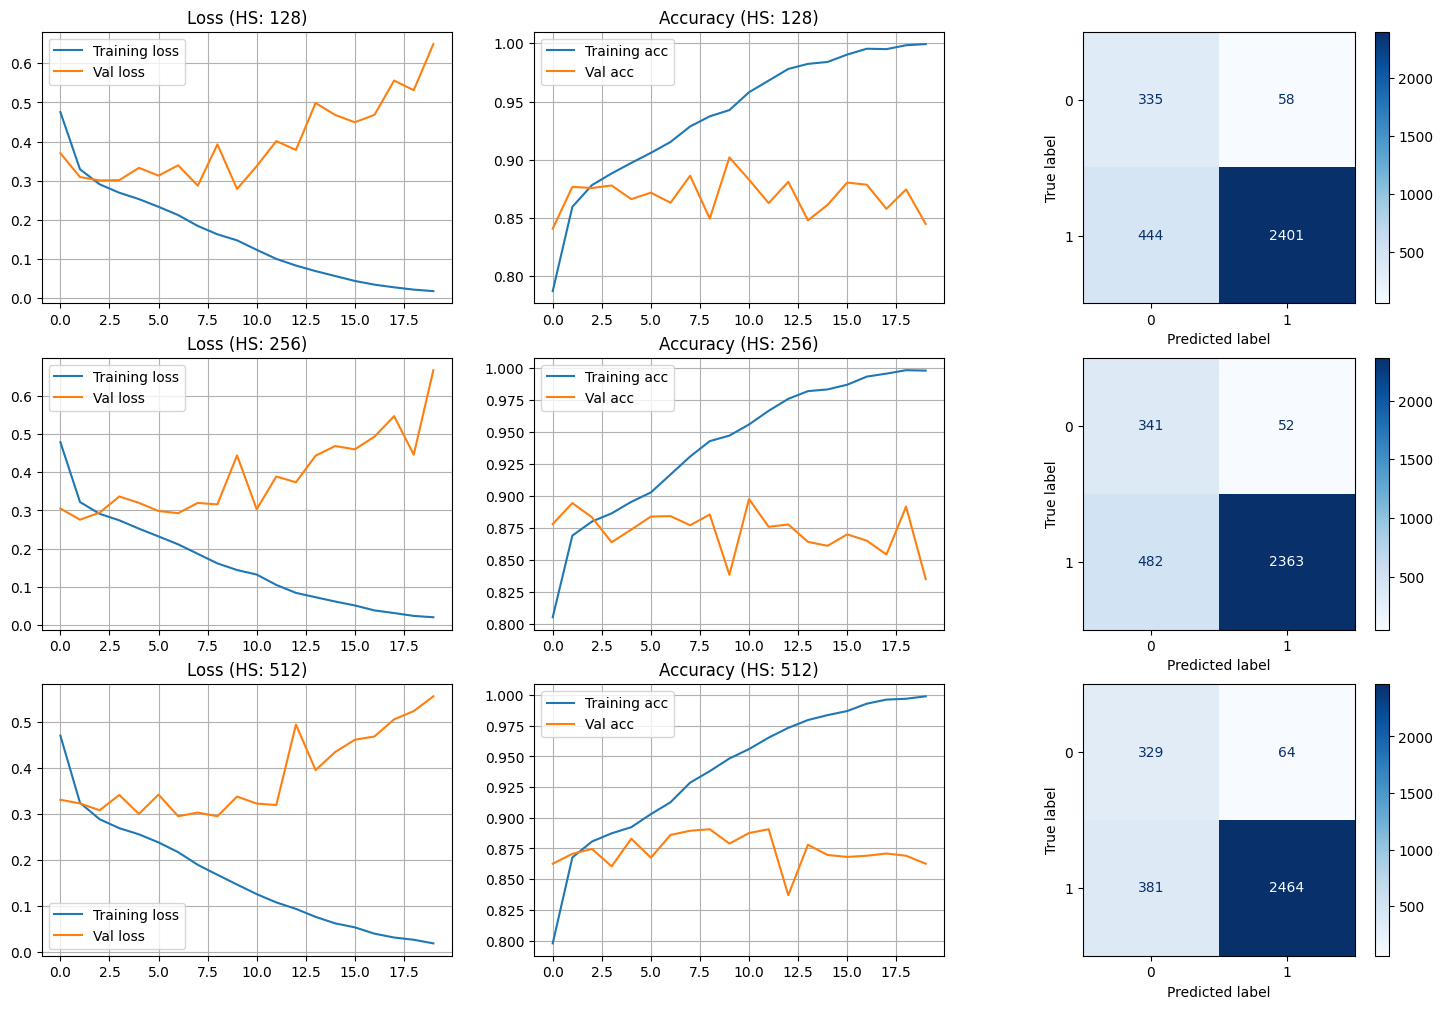

In [14]:
input_size = X_train.shape[-1]
num_epochs = 20

settings = [
    {
        'hidden_size': 128
    },
    {
        'hidden_size': 256
    },
    {
        'hidden_size': 512
    }
]
criterion = nn.CrossEntropyLoss()

fig, axes = plt.subplots(len(settings), 3, figsize=(18, 4 * len(settings)))


for i, setting in enumerate(settings):
    hidden_size = setting['hidden_size']
    print(f"Run {i+1} with hidden_size {hidden_size}.")

    # Create Model
    model = PolarityClassifier(input_size, 512, 2).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    train_losses, val_losses, train_accs, val_accs, total_preds, total_targets = trainer(model, train_loader, test_loader, optimizer, criterion, num_epochs)

    axes[i, 0].plot(train_losses, label='Training loss')
    axes[i, 0].plot(val_losses, label='Val loss')
    axes[i, 0].set_title(f"Loss (HS: {hidden_size})")
    axes[i, 0].legend()
    axes[i, 0].grid()

    axes[i, 1].plot(train_accs, label='Training acc')
    axes[i, 1].plot(val_accs, label='Val acc')
    axes[i, 1].set_title(f"Accuracy (HS: {hidden_size})")
    axes[i, 1].legend()
    axes[i, 1].grid()

    cm = confusion_matrix(torch.cat(total_targets), torch.cat(total_preds))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[i, 2], cmap="Blues")

plt.show()

# Comments
The models seem to be quite good even after the first epoch. Caused by the imbalance by the validation set, the confusion-matrix does not look too promising, however, we reach an accuracy of about 85 to 90%, and on the test-set of almost 100%.

# Analysis

In [41]:
# Sample some words from the test-set (index after 1500)
test_negative_words = random.sample(negative_words[1500:], 10)
test_positive_words = random.sample(positive_words[1500:], 10)

In [42]:
print(test_negative_words)
print(test_positive_words)

['unnerve', 'browbeat', 'addicted', 'bias', 'weirdly', 'contagious', 'kooky', 'unsure', 'whiny', 'irrelevance']
['admirably', 'outstanding', 'advantageously', 'cheaper', 'gainfully', 'fashionable', 'punctual', 'humane', 'trusted', 'workable']


In [44]:
print("Negative Words:")
for word in test_negative_words:
    if word in word_dict:
        vector = torch.tensor(word_dict[word]).to(device)
        pred = model(vector)
        pred_class = torch.argmax(pred)
        print(f"Word {word:>13} is {'negative' if pred_class == 1 else 'positive'} with a probability of {torch.max(F.softmax(pred, dim=-1)) * 100:.2f}%")
    else:
        print(f"Word {word} is not in the dictionary")

print("Positive Words:")
for word in test_positive_words:
    if word in word_dict:
        vector = torch.tensor(word_dict[word]).to(device)
        pred = model(vector)
        pred_class = torch.argmax(pred)
        print(f"Word {word:>13} is {'negative' if pred_class == 1 else 'positive'} with a probability of {torch.max(F.softmax(pred, dim=-1)) * 100:.2f}%")

Negative Words:
Word       unnerve is negative with a probability of 96.86%
Word      browbeat is negative with a probability of 87.57%
Word      addicted is negative with a probability of 99.89%
Word          bias is negative with a probability of 100.00%
Word       weirdly is positive with a probability of 96.66%
Word    contagious is negative with a probability of 99.93%
Word         kooky is positive with a probability of 83.67%
Word        unsure is negative with a probability of 97.25%
Word         whiny is negative with a probability of 99.99%
Word   irrelevance is negative with a probability of 100.00%
Positive Words:
Word     admirably is positive with a probability of 100.00%
Word   outstanding is positive with a probability of 100.00%
Word advantageously is positive with a probability of 99.98%
Word       cheaper is positive with a probability of 100.00%
Word     gainfully is negative with a probability of 99.82%
Word   fashionable is positive with a probability of 87.03%
Wo

# Comments
The Model is correct in 16 out of 19 cases, which the wrong words being a bit strange, as they should be clear in my opinion.

# Average Words

In [65]:
for word in ['average', 'mean', 'gray', 'neutral']:
    if word in word_dict:
        vector = torch.tensor(word_dict[word]).to(device)
        pred = model(vector)
        pred_class = torch.argmax(pred)
        print(f"Word {word:>13} is {'negative' if pred_class == 1 else 'positive'} with a probability of {torch.max(F.softmax(pred, dim=-1)) * 100:.2f}%")

Word       average is positive with a probability of 62.05%
Word          mean is negative with a probability of 74.90%
Word          gray is positive with a probability of 53.77%
Word       neutral is positive with a probability of 99.99%


There are not a lot of words, which are considered neutral by the model